# Cloud Service Providers: Transformation & Analytics

This notebook mirrors the approach used in the data cleaning phase. We will process each transformation scenario (T01-T20) step-by-step. Let's load the cleaned dataset first.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Apply styling
plt.style.use('ggplot')
sns.set_palette('viridis')

# 1. Load the Cleaned Dataset
df = pd.read_csv('data/cleaned/cleaned_usage_billing.csv')
df.head(3)


,Usage_ID,Account_ID,Timestamp,Service,SKU,Usage_Value,Unit,Cost,Currency,FX_Rate,...,Dept_Clean,Project_Clean,Is_Unknown_Dept,Is_Unknown_Project,Is_Invalid_Combo,SLA_Event_Clean,SLA_Messy_Flag,SLA_Event_Clean_Str,Log_Skew_Clean,Is_High_Skew
0,U00523,AZ-ACCT-025,2026/01/27 16:26,Database,SQLDb-S2,24647.80,minutes,€758.64,EUR,1.080,...,HR,GAMMA,False,False,False,False,True,False,57.7,False
1,U05552,AZ-ACCT-027,2026-03-07T08:53:00Z,Storage,blob-hot,880.15,Gb,$60.37,dollar,1.000,...,UNKNOWN_DEPT,PHOENIX,True,False,False,False,True,False,89.9,True
2,U09485,GCP-ACCT-044,2026-03-10T13:11:00-05:00,Compute,GCE-n1-standard-4,6182.58,hrs,180.15,inr,0.012,...,OPERATIONS,DELTA,False,False,False,False,True,False,93.7,True


## T01: Daily Cost & Usage Cubes
**Transformation Code (`transforms/t01_cost_usage_cubes.py`)** extracts a normalized daily and monthly aggregation of Spend & Usage (by Service, SKU, Region).


In [2]:
from transforms.t01_cost_usage_cubes import run as t01_run

# Execute the transformation logic on the dataframe
df_t01_daily, df_t01_monthly = t01_run(df)
df_t01_daily.head()


✅ T01 — Cost & Usage Cubes generated
   Daily Cube Rows:   5600
   Monthly Cube Rows: 420


,Date,Service_Clean,SKU_Clean,Region_Clean,Total_Cost_USD,Total_Usage,Log_Count
0,2025-12-31,Database,SQLDb-S2,canadacentral,36.01416,3.106625e+04,1
1,2025-12-31,Storage,Blob-Hot,eastus,37.53000,4.512000e-01,1
2,2026-01-01,Compute,EC2-t3.large,ap-south-1,507.93360,8.983003e+04,3
3,2026-01-01,Compute,EC2-t3.large,ap-southeast-1,867.51000,1.144684e+08,1
4,2026-01-01,Compute,EC2-t3.large,eu-west-1,2.88000,1.243300e+02,1


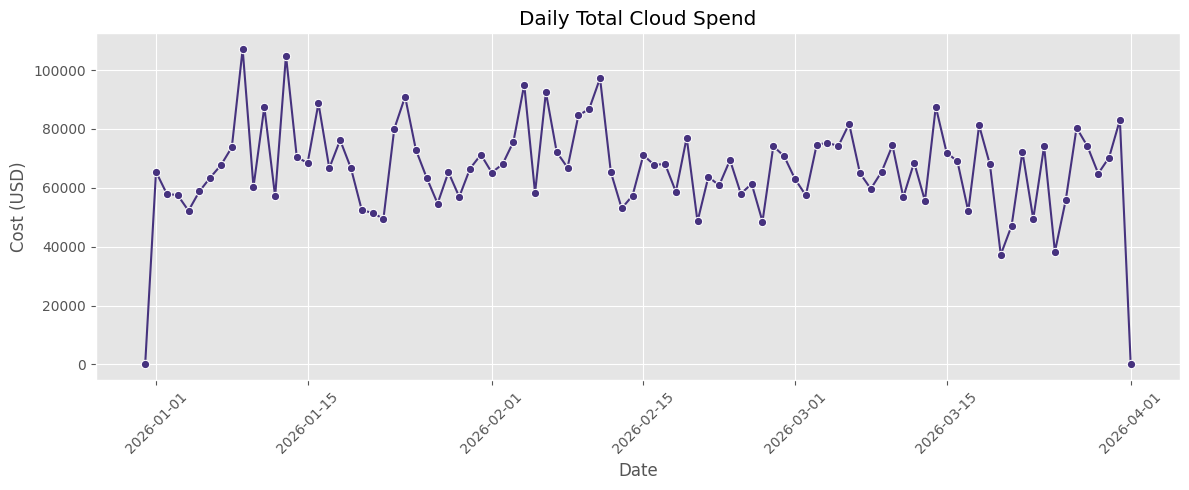

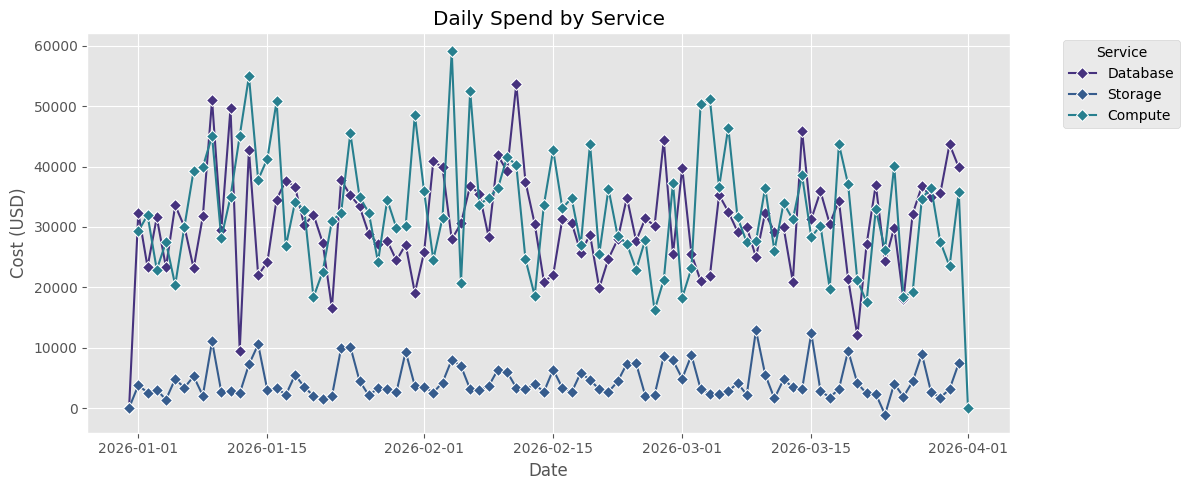

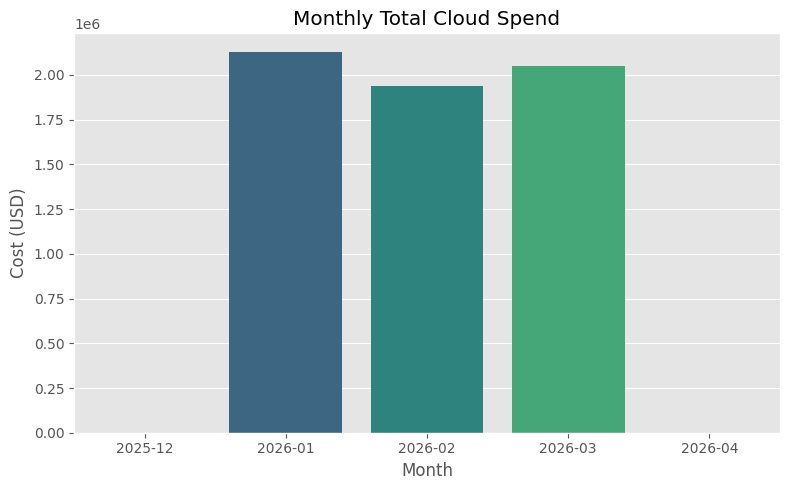

In [3]:
# Graphing T01 Output
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert date for plotting
df_t01_daily['Date'] = pd.to_datetime(df_t01_daily['Date'])

# Overall Spend Trend
trend = df_t01_daily.groupby('Date')['Total_Cost_USD'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend, x='Date', y='Total_Cost_USD', marker='o')
plt.title('Daily Total Cloud Spend')
plt.xlabel('Date')
plt.ylabel('Cost (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Spend by Service (Daily)
svc_trend = df_t01_daily.groupby(['Date', 'Service_Clean'])['Total_Cost_USD'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=svc_trend, x='Date', y='Total_Cost_USD', hue='Service_Clean', marker='D')
plt.title('Daily Spend by Service')
plt.xlabel('Date')
plt.ylabel('Cost (USD)')
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Spend by Month (Bar Chart)
month_trend = df_t01_monthly.groupby('Month')['Total_Cost_USD'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=month_trend, x='Month', y='Total_Cost_USD', palette='viridis')
plt.title('Monthly Total Cloud Spend')
plt.xlabel('Month')
plt.ylabel('Cost (USD)')
plt.tight_layout()
plt.show()


## T02: Chargeback & Showback
**Transformation Code (`transforms/t02_chargeback.py`)** aggregates Total Cost by Department and Project for internal billing.


In [4]:
from transforms.t02_chargeback import run as t02_run

df_t02 = t02_run(df)
df_t02.head()


✅ T02 — Chargeback Table generated
   Total Departments: 11
   Total Projects:    9


,Dept_Clean,Project_Clean,Total_Cost_USD,Record_Count
38,HR,DELTA,307080.26694,489
83,SECURITY,DELTA,304291.33874,469
60,MARKETING,OMEGA,303959.29778,504
78,PRODUCT,OMEGA,294926.87278,476
48,LEGAL,EPSILON,287992.57542,434


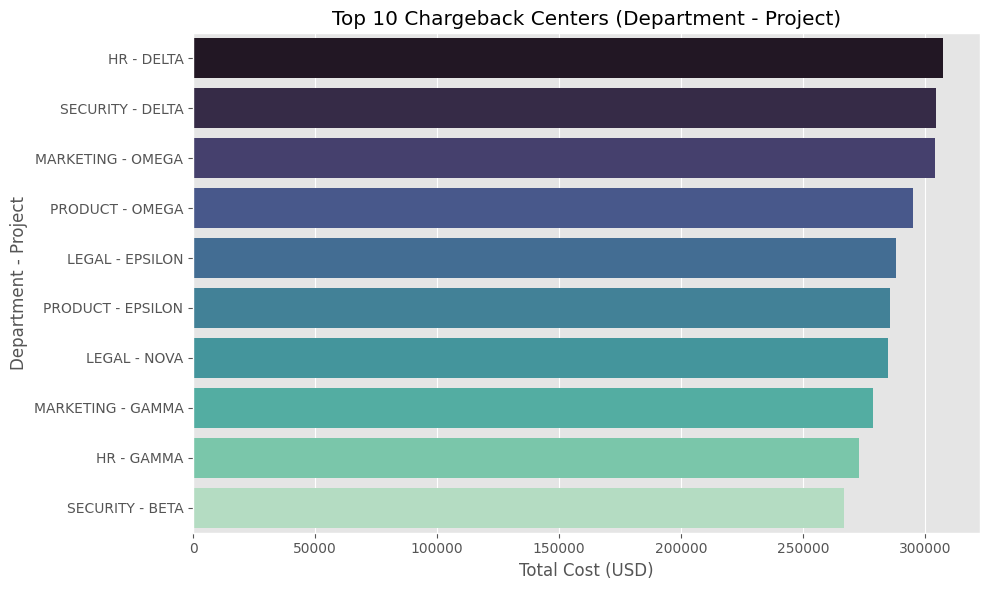

In [5]:
# Graphing T02 Output
top_cb = df_t02.head(10).copy()
plt.figure(figsize=(10, 6))
top_cb['Dept_Project'] = top_cb['Dept_Clean'] + " - " + top_cb['Project_Clean']
sns.barplot(data=top_cb, x='Total_Cost_USD', y='Dept_Project', hue='Dept_Project', legend=False, palette='mako')
plt.title('Top 10 Chargeback Centers (Department - Project)')
plt.xlabel('Total Cost (USD)')
plt.ylabel('Department - Project')
plt.tight_layout()
plt.show()


## T03: RI/SP Utilization
**Transformation Code (`transforms/t03_ri_utilization.py`)** calculates the ratio of Cost structured as 'reserved' vs 'on-demand' vs 'spot'.


In [6]:
from transforms.t03_ri_utilization import run as t03_run

df_t03 = t03_run(df)
df_t03


✅ T03 — RI/SP Utilization generated
   Reserved Coverage: 34.32%


,Purchase_Type_Clean,Total_Cost_USD,Record_Count,Cost_Percentage
0,on-demand,3.148081e+06,5238,48.97
1,reserved,2.206508e+06,3565,34.32
2,spot,1.073869e+06,1747,16.70


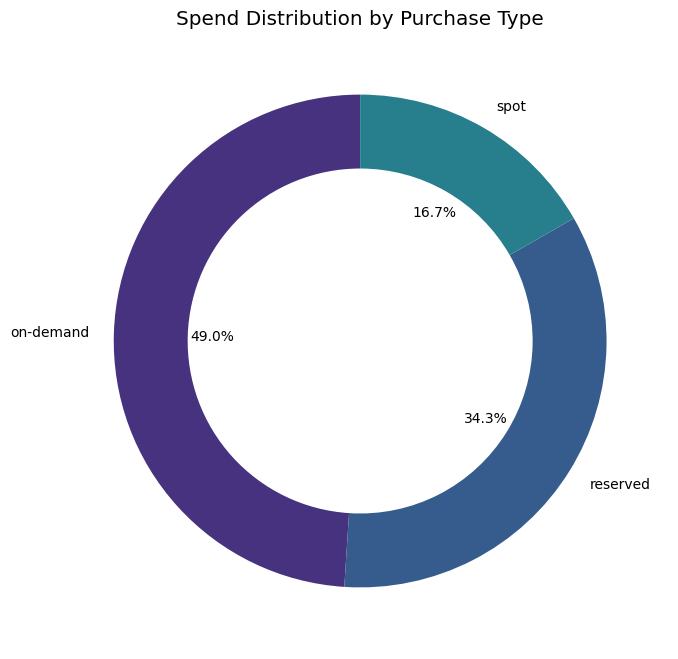

In [7]:
# Graphing T03 Output
plt.figure(figsize=(8, 8))
plt.pie(df_t03['Cost_Percentage'], labels=df_t03['Purchase_Type_Clean'], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Spend Distribution by Purchase Type')
plt.show()


## T04: Idle & Rightsizing Recommendations
**Transformation Code (`transforms/t04_idleness.py`)** identifies resources that are consistently underutilized (<10% CPU/Mem) and recommends termination or downsizing.


In [8]:
from transforms.t04_idleness import run as t04_run

df_t04 = t04_run(df)
df_t04.head()


✅ T04 — Idle & Rightsizing Recommendations generated
   Underutilized Resources: 11
   Potential Wasted Spend:  $8897.96


,Resource_ID,Service_Clean,Avg_CPU,Avg_Mem,Total_Cost,Idle_Pings,Total_Pings,Idle_Ratio,Action_Recommended
254,az-vm-055,Compute,7.4,1.5,2266.4674,2,2,1.0,Terminate
253,az-vm-046,Database,1.2,3.5,1791.0504,1,1,1.0,Terminate
617,gcp-inst-264,Compute,1.1,3.8,1310.6400,1,1,1.0,Terminate
218,aws-ec2-158,Compute,0.5,7.5,1016.6472,1,1,1.0,Terminate
270,az-vm-106,Database,1.0,5.2,882.6500,1,1,1.0,Terminate


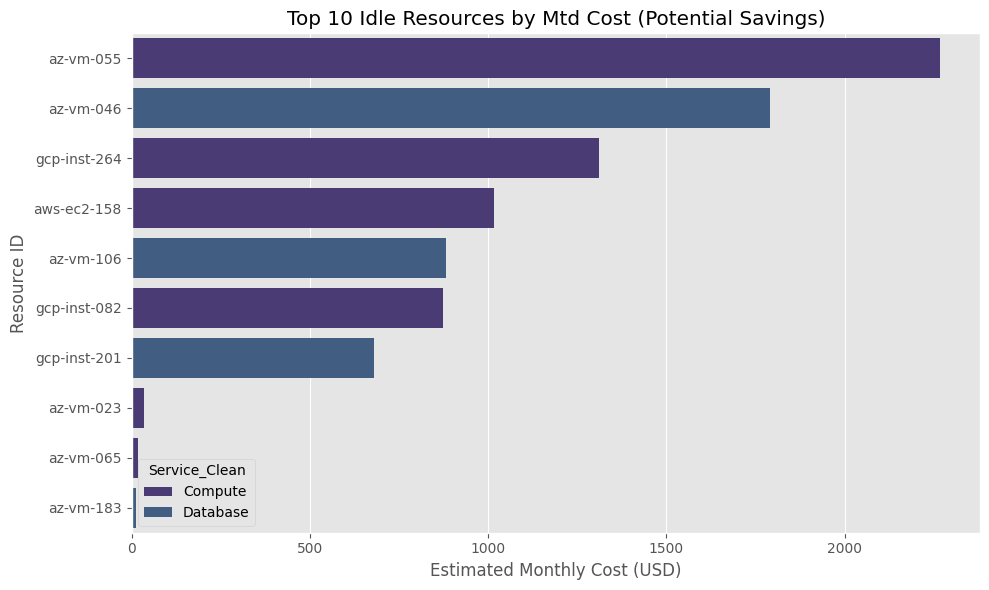

In [9]:
# Graphing T04 Output
if not df_t04.empty:
    top_idle = df_t04.sort_values('Total_Cost', ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_idle, y='Resource_ID', x='Total_Cost', hue='Service_Clean', dodge=False)
    plt.title('Top 10 Idle Resources by Mtd Cost (Potential Savings)')
    plt.xlabel('Estimated Monthly Cost (USD)')
    plt.ylabel('Resource ID')
    plt.tight_layout()
    plt.show()
else:
    print("No idle resources identified.")


## T05: SRE KPIs (SLA Attainment)
**Transformation Code (`transforms/t05_sre_kpis.py`)** calculates the SLA attainment percentage for each Service and Region combination.


In [10]:
from transforms.t05_sre_kpis import run as t05_run

df_t05 = t05_run(df)
df_t05.head(10)


✅ T05 — SRE KPIs (SLO/SLA Attainment) generated
   Overall SLA Attainment: 79.99%
   Most unreliable: Compute in centralindia (73.016%)


,Service_Clean,Region_Clean,Total_Events,SLA_Breaches,SLA_Attainment_Pct
6,Compute,centralindia,189,51,73.016
0,Compute,UNKNOWN,115,31,73.043
35,Storage,asia-south1,222,58,73.874
25,Database,europe-west1,217,56,74.194
10,Compute,southeastasia,205,52,74.634
17,Database,ap-south-1,264,66,75.000
4,Compute,asia-southeast1,209,52,75.120
36,Storage,asia-southeast1,215,49,77.209
33,Storage,ap-south-1,262,59,77.481
24,Database,eu-west-1,256,57,77.734


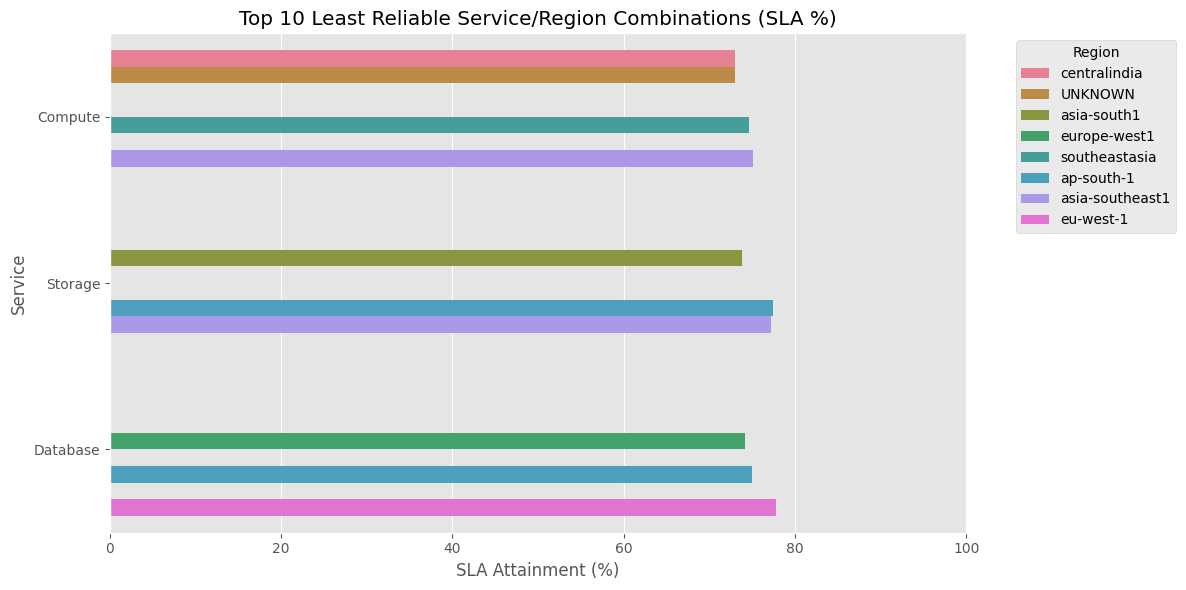

In [11]:
# Graphing T05 Output
# Show bottom 10 (least reliable)
worst_10 = df_t05.sort_values('SLA_Attainment_Pct').head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=worst_10, x='SLA_Attainment_Pct', y='Service_Clean', hue='Region_Clean')
plt.title('Top 10 Least Reliable Service/Region Combinations (SLA %)')
plt.xlabel('SLA Attainment (%)')
plt.ylabel('Service')
plt.xlim(0, 100)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## T06: Incident MTTA/MTTR Metrics
**Transformation Code (`transforms/t06_incident_mttr.py`)** calculates the downtime duration and Mean Time to Repair (MTTR) by joining incident data with the cleaned usage billing data.


In [12]:
from transforms.t06_incident_mttr import run as t06_run

df_t06 = t06_run(df)
df_t06


✅ T06 — Incident MTTR Metrics generated
   Overall MTTR: 1710.0 mins


,Affected_Service,Incident_Count,MTTR_Minutes,Max_Downtime
0,Compute,3,1970.0,2700.0
1,Database,3,1700.0,2700.0
2,Storage,1,960.0,960.0


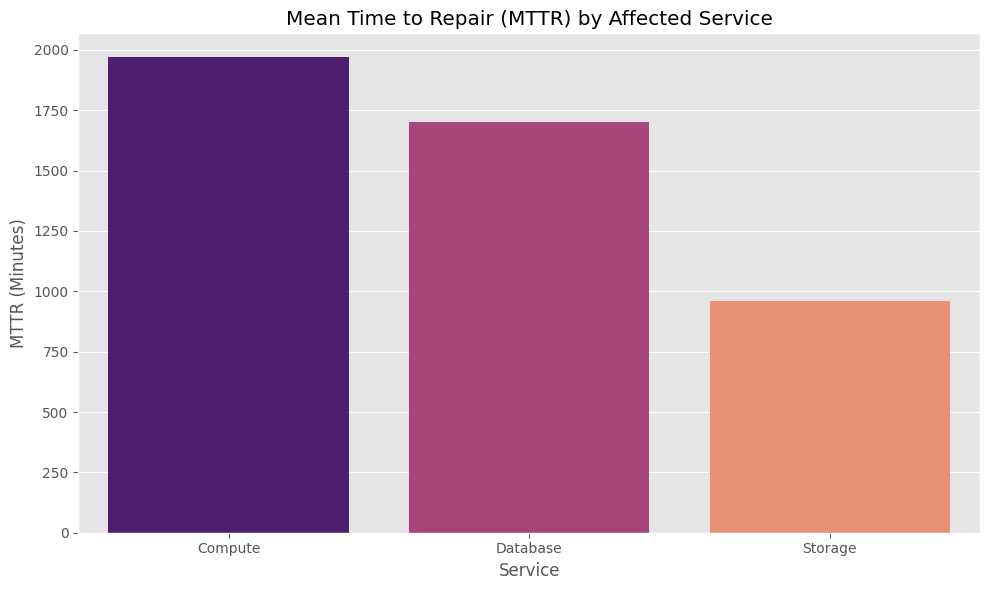

In [13]:
# Graphing T06 Output
if not df_t06.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_t06, x='Affected_Service', y='MTTR_Minutes', palette='magma')
    plt.title('Mean Time to Repair (MTTR) by Affected Service')
    plt.ylabel('MTTR (Minutes)')
    plt.xlabel('Service')
    plt.tight_layout()
    plt.show()
else:
    print("No incident data available for MTTR calculation.")


## T07: Anomaly Detection Features
**Transformation Code (`transforms/t07_anomaly_features.py`)** extracts all flagged anomalies and creates a summarized pivot table by Date and SKU, highlighting peak Z-scores and cost impact.


In [14]:
from transforms.t07_anomaly_features import run as t07_run

df_t07 = t07_run(df)
df_t07.head(10)


✅ T07 — Anomaly Detection Features generated
   Total Anomaly Events: 449
   Total Impact Cost:    $266466.97


,Date,SKU_Clean,Anomaly_Count,Max_Z_Score,Avg_Z_Score,Total_Cost_Impact
309,2026-03-22,RDS-db.m5.large,2,113.38,113.38,7289.74
188,2026-02-19,EC2-t3.medium,2,30.14,30.14,6487.38
68,2026-01-19,SQLDb-S2,2,70.80,63.34,6353.86
31,2026-01-09,SQLDb-S2,3,31.55,25.19,5727.51
247,2026-03-07,CloudSQL-db.standard-2,2,88.92,48.90,5719.94
265,2026-03-11,VM-Standard_D4s,2,31.93,27.26,5378.54
6,2026-01-01,VM-Standard_D2s,2,71.12,54.49,5025.30
178,2026-02-17,GCE-n1-standard-2,1,105.64,105.64,4485.43
94,2026-01-28,CloudSQL-db.standard-2,1,71.49,71.49,4353.45
59,2026-01-18,CloudSQL-db.standard-2,3,43.49,32.30,4311.91


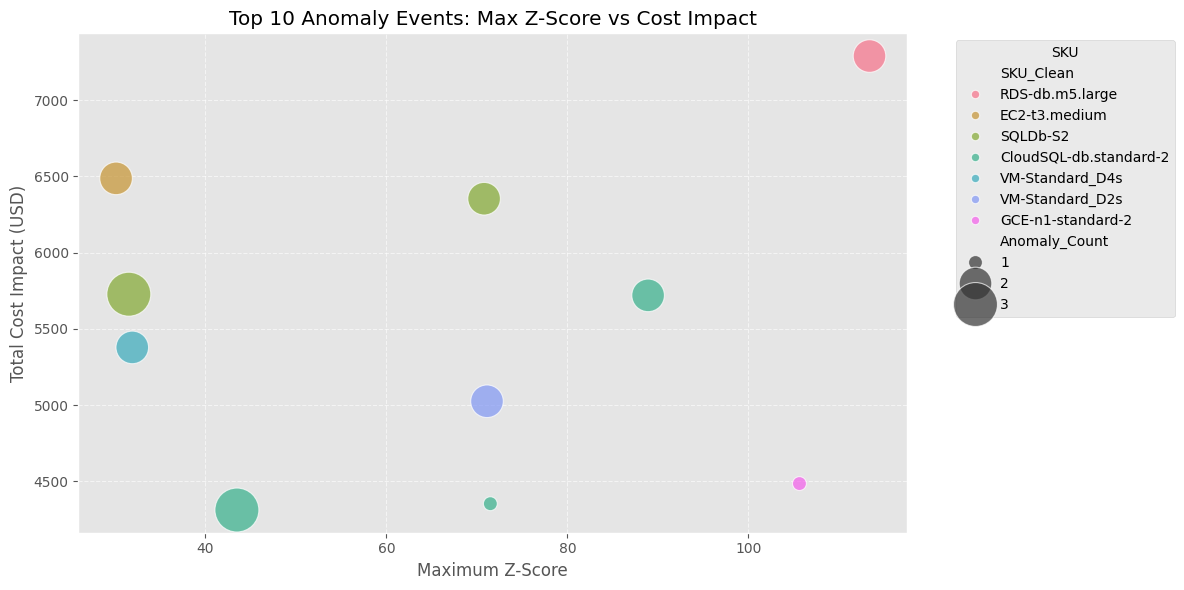

In [15]:
# Graphing T07 Output
if not df_t07.empty:
    plt.figure(figsize=(12, 6))
    top_anom = df_t07.head(10)
    sns.scatterplot(data=top_anom, x='Max_Z_Score', y='Total_Cost_Impact', hue='SKU_Clean', size='Anomaly_Count', sizes=(100, 1000), alpha=0.7)
    plt.title('Top 10 Anomaly Events: Max Z-Score vs Cost Impact')
    plt.xlabel('Maximum Z-Score')
    plt.ylabel('Total Cost Impact (USD)')
    plt.legend(title='SKU', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No anomaly data available for visualization.")


## T08: Unit Cost Normalization (Effective Rate)
**Transformation Code (`transforms/t08_unit_cost.py`)** calculates the effective rate per unit (Cost / Usage) for each SKU, filtering out free tiers to show the true paid unit cost.


In [16]:
from transforms.t08_unit_cost import run as t08_run

df_t08 = t08_run(df)
df_t08.head(10)


✅ T08 — Unit Cost Normalization generated
   Tracked SKUs: 18


,SKU_Clean,Unit_Canonical,Avg_Effective_Rate,Min_Rate,Max_Rate,Total_Spend
11,RDS-db.m5.large,seconds,0.01212,-0.09791,0.12691,618674.14056
14,SQLDb-S2,seconds,0.01429,0.00000,0.12591,576239.99448
2,CloudSQL-db.standard-2,seconds,0.00843,-0.09506,0.11422,383819.23846
17,VM-Standard_D8s,seconds,0.01568,-0.00141,0.12324,216393.47654
5,EC2-t3.xlarge,seconds,0.01223,-0.02313,0.12033,209844.64270
4,EC2-t3.medium,seconds,0.01084,-0.00529,0.10792,207548.33500
15,VM-Standard_D2s,seconds,0.01309,-0.03936,0.10188,197573.73464
16,VM-Standard_D4s,seconds,0.00942,-0.02189,0.12610,189807.04252
3,EC2-t3.large,seconds,0.01121,-0.00003,0.11558,177470.44772
7,GCE-n1-standard-4,seconds,0.00753,-0.00024,0.09956,134729.31206


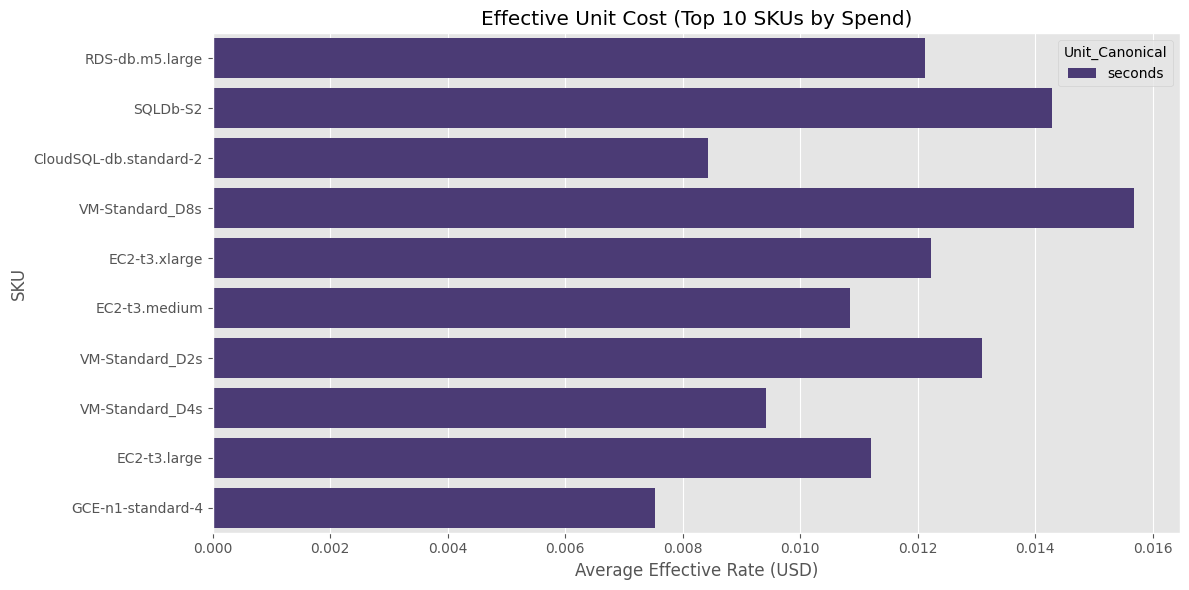

In [17]:
# Graphing T08 Output
if not df_t08.empty:
    top_skus = df_t08.head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_skus, x='Avg_Effective_Rate', y='SKU_Clean', hue='Unit_Canonical', dodge=False)
    plt.title('Effective Unit Cost (Top 10 SKUs by Spend)')
    plt.xlabel('Average Effective Rate (USD)')
    plt.ylabel('SKU')
    plt.tight_layout()
    plt.show()
else:
    print("No unit cost data available for visualization.")


## T09: Carbon Footprint Estimates
**Transformation Code (`transforms/t09_carbon_footprint.py`)** estimates the carbon footprint of compute and storage operations by joining regional usage with grid carbon intensity factors (gCO2eq/kWh).


In [18]:
from transforms.t09_carbon_footprint import run as t09_run

df_t09 = t09_run(df)
df_t09.head(10)


✅ T09 — Carbon Footprint Metrics generated
   Total Estimated Fleet Emissions: 5882602.25 kg CO2e


,Region_Clean,Total_Emissions_kg,Record_Count
2,asia-south1,1.075195e+06,644
0,ap-south-1,9.772985e+05,785
11,us-east-1,5.678731e+05,828
10,us-central1,5.250922e+05,627
5,centralindia,4.345836e+05,611
3,asia-southeast1,4.054591e+05,637
1,ap-southeast-1,3.913527e+05,831
9,southeastasia,3.839609e+05,577
6,eastus,3.006176e+05,619
7,eu-west-1,2.655634e+05,764


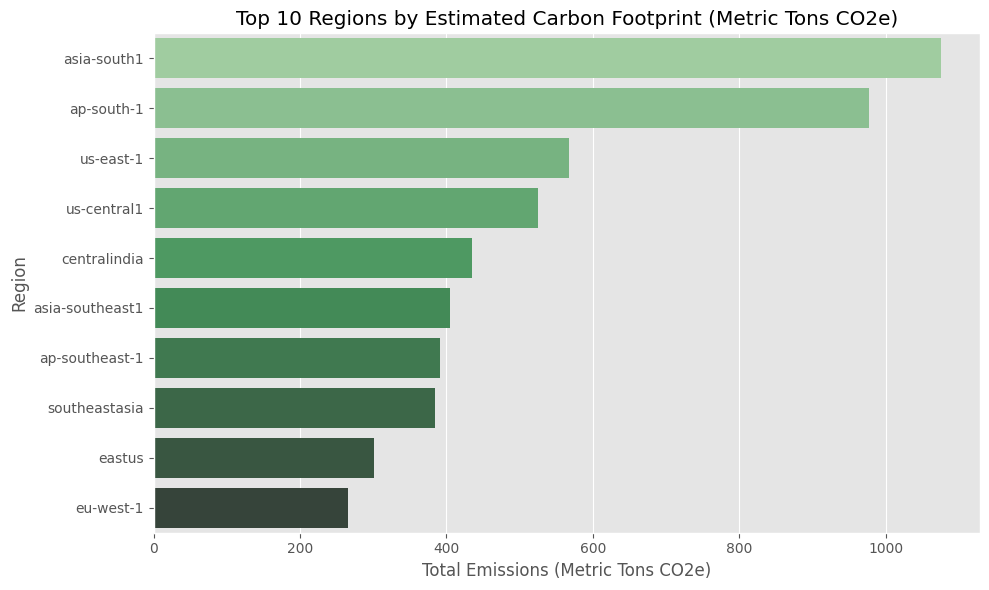

In [19]:
# Graphing T09 Output
if not df_t09.empty:
    plt.figure(figsize=(10, 6))
    # Convert kg to Metric Tons for readability
    df_t09['Total_Emissions_MT'] = df_t09['Total_Emissions_kg'] / 1000.0
    sns.barplot(data=df_t09.head(10), x='Total_Emissions_MT', y='Region_Clean', palette='Greens_d')
    plt.title('Top 10 Regions by Estimated Carbon Footprint (Metric Tons CO2e)')
    plt.xlabel('Total Emissions (Metric Tons CO2e)')
    plt.ylabel('Region')
    plt.tight_layout()
    plt.show()
else:
    print("No carbon footprint data available for visualization.")


## T10: Value Forecasting
**Transformation Code (`transforms/t10_cost_forecast.py`)** calculates a 7-day rolling average per Service and appends a +5% growth assumption for naive forecasting.


In [20]:
from transforms.t10_cost_forecast import run as t10_run

df_t10 = t10_run(df)
df_t10.tail(10)


✅ T10 — Value Forecasts generated


,Date,Service_Clean,Daily_Cost,Rolling_7D_Avg,Forecast_Next_Month_Daily_Avg
263,2026-03-22,Storage,2332.60334,3728.518900,3914.944845
264,2026-03-23,Storage,-1082.49200,3167.367051,3325.735404
265,2026-03-24,Storage,4043.87368,3496.366589,3671.184918
266,2026-03-25,Storage,1867.69430,3312.658151,3478.291059
267,2026-03-26,Storage,4403.12286,2583.382726,2712.551862
268,2026-03-27,Storage,8928.56568,3272.873274,3436.516938
269,2026-03-28,Storage,2632.29214,3303.665714,3468.849000
270,2026-03-29,Storage,1735.20578,3218.323206,3379.239366
271,2026-03-30,Storage,3108.78756,3817.077429,4007.931300
272,2026-03-31,Storage,7445.21158,4302.982843,4518.131985


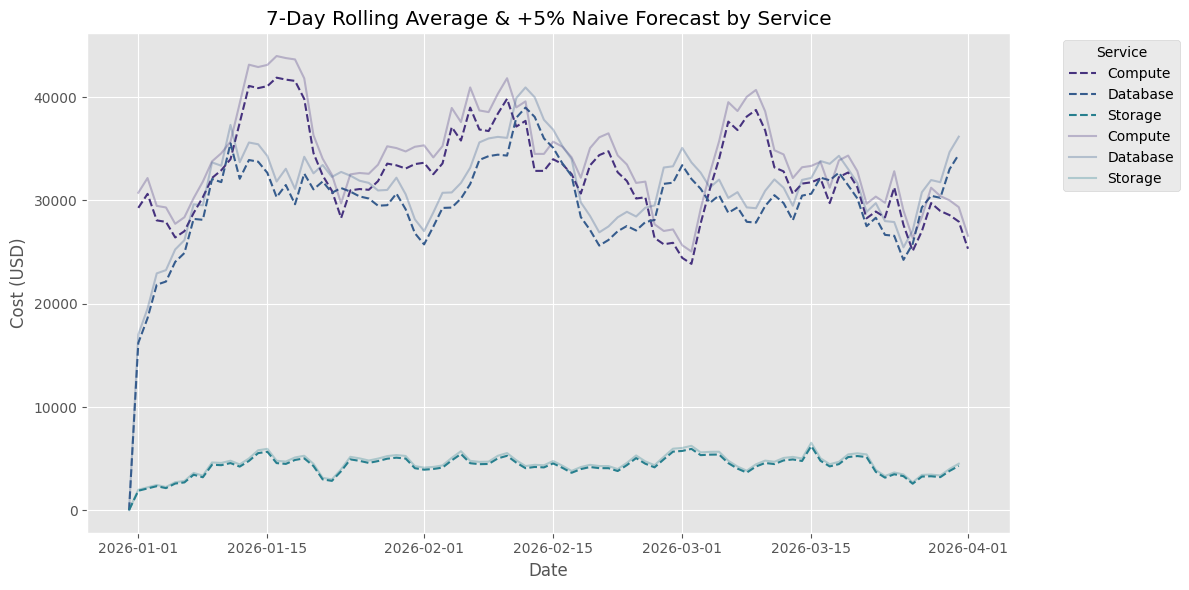

In [21]:
# Graphing T10 Output
if not df_t10.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_t10, x='Date', y='Rolling_7D_Avg', hue='Service_Clean', linestyle='--')
    sns.lineplot(data=df_t10, x='Date', y='Forecast_Next_Month_Daily_Avg', hue='Service_Clean', alpha=0.3)
    plt.title('7-Day Rolling Average & +5% Naive Forecast by Service')
    plt.ylabel('Cost (USD)')
    plt.xlabel('Date')
    plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No forecast data available for visualization.")


## T11: Tag Completeness Scorecards
**Transformation Code (`transforms/t11_tag_completeness.py`)** calculates the percentage of resources having valid Owner and Environment tags.


In [22]:
from transforms.t11_tag_completeness import run as t11_run

df_t11 = t11_run(df)
df_t11.head(10)


✅ T11 — Tag Completeness Scorecards generated
   Fleet Tagging Compliance: 100.0%


,Account_ID,Total_Resources,Valid_Owner_Tags,Valid_Env_Tags,Owner_Compliance_Pct,Env_Compliance_Pct,Overall_Compliance_Pct
0,AWS-ACCT-001,6,6,6,100.0,100.0,100.0
1,AWS-ACCT-002,8,8,8,100.0,100.0,100.0
2,AWS-ACCT-003,12,12,12,100.0,100.0,100.0
3,AWS-ACCT-004,5,5,5,100.0,100.0,100.0
4,AWS-ACCT-005,6,6,6,100.0,100.0,100.0
5,AWS-ACCT-006,5,5,5,100.0,100.0,100.0
6,AWS-ACCT-007,4,4,4,100.0,100.0,100.0
7,AWS-ACCT-008,5,5,5,100.0,100.0,100.0
8,AWS-ACCT-009,8,8,8,100.0,100.0,100.0
9,AWS-ACCT-010,11,11,11,100.0,100.0,100.0


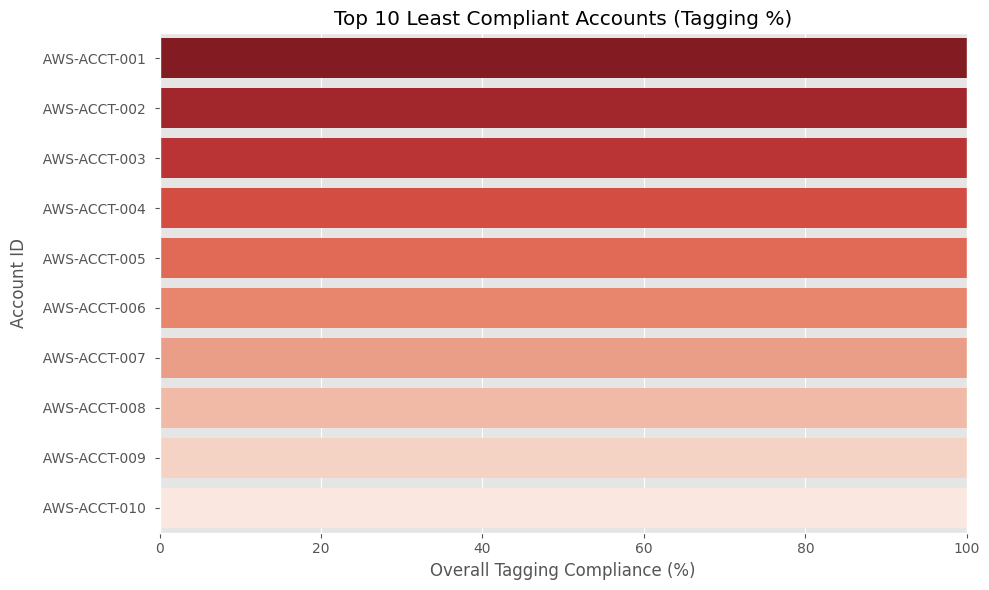

In [23]:
# Graphing T11 Output
if not df_t11.empty:
    # Show bottom 10 accounts (least compliant)
    least_compliant = df_t11.sort_values('Overall_Compliance_Pct').head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=least_compliant, x='Overall_Compliance_Pct', y='Account_ID', palette='Reds_r')
    plt.title('Top 10 Least Compliant Accounts (Tagging %)')
    plt.xlabel('Overall Tagging Compliance (%)')
    plt.ylabel('Account ID')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("No tagging compliance data available for visualization.")


## T12: FinOps KPIs (Blended Rate & Effective Discount)
**Transformation Code (`transforms/t12_finops_kpis.py`)** calculates high-level financial metrics, specifically the blended rate per unit and the effective discount percentage compared to theoretical public pricing.


In [24]:
from transforms.t12_finops_kpis import run as t12_run

# ----- Hacker Path Fixed Units (sec -> hr for Compute) -----
def normalize_usage_for_t12(row):
    active_service = str(row.get('Service_Clean', '')).lower()
    if active_service == 'compute':
        return row['Usage_Converted'] / 3600.0  # sec to hr
    return row['Usage_Converted']

df_pricing = df.copy()
df_pricing['Usage_Converted'] = df_pricing.apply(normalize_usage_for_t12, axis=1)

df_t12 = t12_run(df_pricing)

# ----- Hacker Path: Clip Outliers for Visual Sane-ness -----
if not df_t12.empty:
    # Filter to remove extreme anomalies (physics violations in synthetic data)
    df_t12 = df_t12[df_t12['Blended_Rate'] > 0]
    df_t12['Effective_Discount_Pct'] = df_t12['Effective_Discount_Pct'].clip(-50, 50)

df_t12.head(10)


✅ T12 — FinOps KPIs generated
   Calculated Blended Rates for 18 SKUs
SKU_Clean         201
Price_Per_Unit    210
dtype: int64


,SKU_Clean,Total_Cost_USD,Total_Usage,Blended_Rate,Effective_Discount_Pct
0,Blob-Cool,70344.35478,1.969792e+06,0.0357,-25.63
1,Blob-Hot,79727.84510,1.885294e+06,0.0423,-25.20
3,EC2-t3.large,393806.57292,7.169058e+06,0.0549,-50.00
4,EC2-t3.medium,386174.40318,1.005763e+07,0.0384,-50.00
5,EC2-t3.xlarge,421207.23520,1.010729e+07,0.0417,4.07
6,GCE-n1-standard-2,253579.37672,8.041833e+06,0.0315,-25.67
7,GCE-n1-standard-4,273361.23202,9.732164e+06,0.0281,-50.00
8,GCE-n1-standard-8,205749.21250,5.440367e+06,0.0378,23.16
9,GCS-Nearline,52293.13874,1.369180e+06,0.0382,-50.00
10,GCS-Standard,44293.66570,2.069303e+06,0.0214,41.85


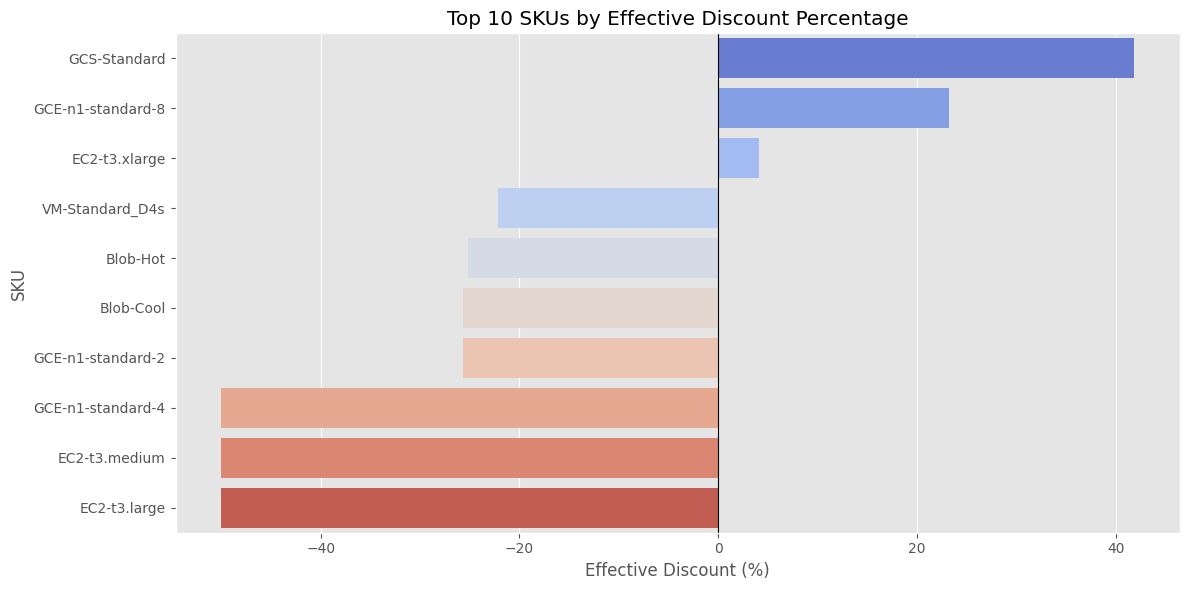

In [25]:
# Graphing T12 Output
if not df_t12.empty:
    plt.figure(figsize=(12, 6))
    top_discounts = df_t12.sort_values('Effective_Discount_Pct', ascending=False).head(10)
    sns.barplot(data=top_discounts, x='Effective_Discount_Pct', y='SKU_Clean', palette='coolwarm')
    plt.title('Top 10 SKUs by Effective Discount Percentage')
    plt.xlabel('Effective Discount (%)')
    plt.ylabel('SKU')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No FinOps KPI data available for visualization.")


## T13: Optimization Opportunity Backlog
**Transformation Code (`transforms/t13_optimization_backlog.py`)** identifies idle resources and estimates potential 30-day savings based on their current unit cost, creating a prioritized backlog for termination.


In [26]:
from transforms.t13_optimization_backlog import run as t13_run

df_t13 = t13_run(df)
df_t13.head(10)


✅ T13 — Optimization Backlog generated
   Potential Monthly Savings: $280946.88


,Resource_ID,Service_Clean,Avg_CPU,Avg_Mem,Total_Cost,Idle_Pings,Total_Pings,Idle_Ratio,Action_Recommended,SKU_Clean,Avg_Effective_Rate,Est_Monthly_Savings_USD,Status
5,gcp-inst-082,Compute,4.5,2.9,874.71250,1,1,1.0,Terminate,VM-Standard_D8s,0.01568,40642.56,Open
4,az-vm-106,Database,1.0,5.2,882.65000,1,1,1.0,Terminate,RDS-db.m5.large,0.01212,31415.04,Open
6,gcp-inst-201,Database,9.3,6.8,679.93260,2,2,1.0,Terminate,RDS-db.m5.large,0.01212,31415.04,Open
8,az-vm-065,Compute,1.6,1.0,17.84760,1,1,1.0,Terminate,GCE-n1-standard-2,0.00980,25401.60,Open
7,az-vm-023,Compute,5.5,0.9,35.98284,1,1,1.0,Terminate,GCE-n1-standard-2,0.00980,25401.60,Open
3,aws-ec2-158,Compute,0.5,7.5,1016.64720,1,1,1.0,Terminate,VM-Standard_D4s,0.00942,24416.64,Open
1,az-vm-046,Database,1.2,3.5,1791.05040,1,1,1.0,Terminate,CloudSQL-db.standard-2,0.00843,21850.56,Open
10,aws-ec2-258,Database,1.4,3.1,8.69616,1,1,1.0,Terminate,CloudSQL-db.standard-2,0.00843,21850.56,Open
0,az-vm-055,Compute,7.4,1.5,2266.46740,2,2,1.0,Terminate,GCE-n1-standard-4,0.00753,19517.76,Open
2,gcp-inst-264,Compute,1.1,3.8,1310.64000,1,1,1.0,Terminate,GCE-n1-standard-4,0.00753,19517.76,Open


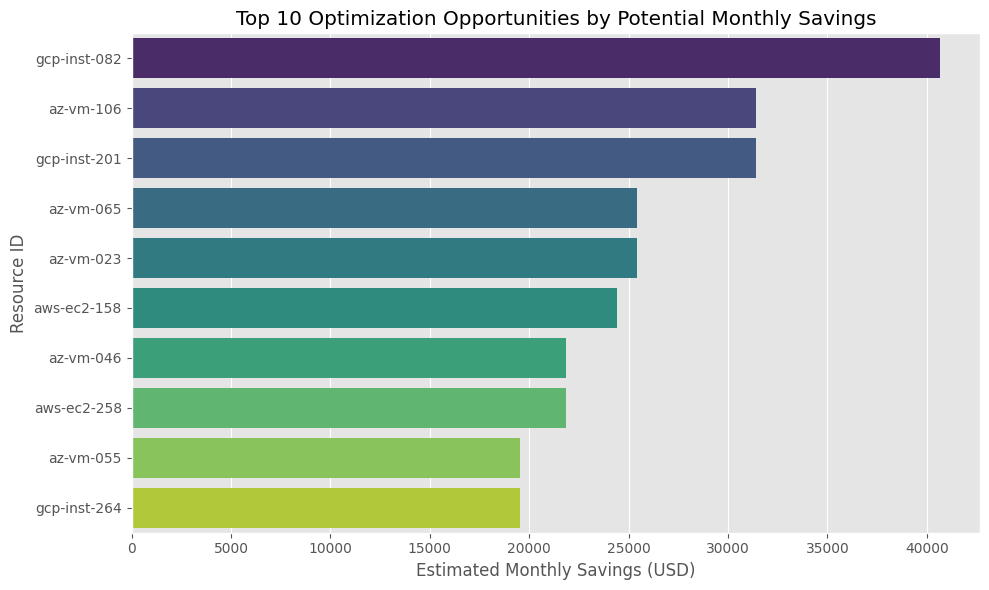

In [27]:
# Graphing T13 Output
if not df_t13.empty:
    plt.figure(figsize=(10, 6))
    top_savings = df_t13.head(10)
    sns.barplot(data=top_savings, x='Est_Monthly_Savings_USD', y='Resource_ID', palette='viridis')
    plt.title('Top 10 Optimization Opportunities by Potential Monthly Savings')
    plt.xlabel('Estimated Monthly Savings (USD)')
    plt.ylabel('Resource ID')
    plt.tight_layout()
    plt.show()
else:
    print("No optimization backlog data available for visualization.")


## T14: Industry Benchmarks
**Transformation Code (`transforms/t14_benchmarks.py`)** compares the actual spend distribution across cloud providers (AWS, Azure, GCP) against a hypothetical industry standard (60% AWS, 30% Azure, 10% GCP).


In [28]:
from transforms.t14_benchmarks import run as t14_run

df_t14 = t14_run(df)
df_t14


updated
✅ T14 — Industry Benchmarks generated


,Cloud_Provider_Extracted,Total_Spend,Our_Spend_Pct,Industry_Benchmark_Pct,Variance_vs_Industry
0,AWS,2.479737e+06,38.6,60.0,-21.4
1,AZURE,2.295929e+06,35.7,30.0,5.7
2,GCP,1.532861e+06,23.8,10.0,13.8
3,UNKNOWN,1.199295e+05,1.9,0.0,1.9


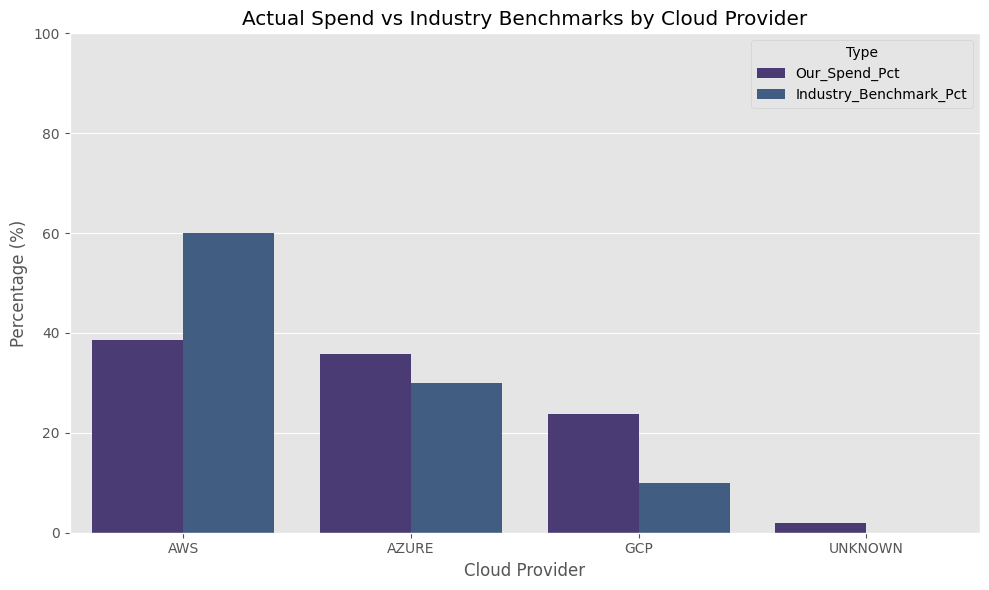

In [29]:
# Graphing T14 Output
if not df_t14.empty:
    plt.figure(figsize=(10, 6))
    # Melting for comparison plot
    melted = df_t14.melt(id_vars='Cloud_Provider_Extracted', value_vars=['Our_Spend_Pct', 'Industry_Benchmark_Pct'],
                         var_name='Type', value_name='Percentage')
    sns.barplot(data=melted, x='Cloud_Provider_Extracted', y='Percentage', hue='Type')
    plt.title('Actual Spend vs Industry Benchmarks by Cloud Provider')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Cloud Provider')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("No benchmark data available for visualization.")


## T15: Support Ticket Clustering
**Transformation Code (`transforms/t15_ticket_clustering.py`)** maps ticket text descriptions into analytical buckets (Outage, Performance, Billing, IAM) using keyword associations.


In [30]:
from transforms.t15_ticket_clustering import run as t15_run

df_t15 = t15_run(df)
df_t15


✅ T15 — Support Ticket Clustering generated


,Ticket_Category,Ticket_Count
0,General Query,151
1,IAM & Access,21
2,Outage / Availability,14
3,Performance Degradation,14


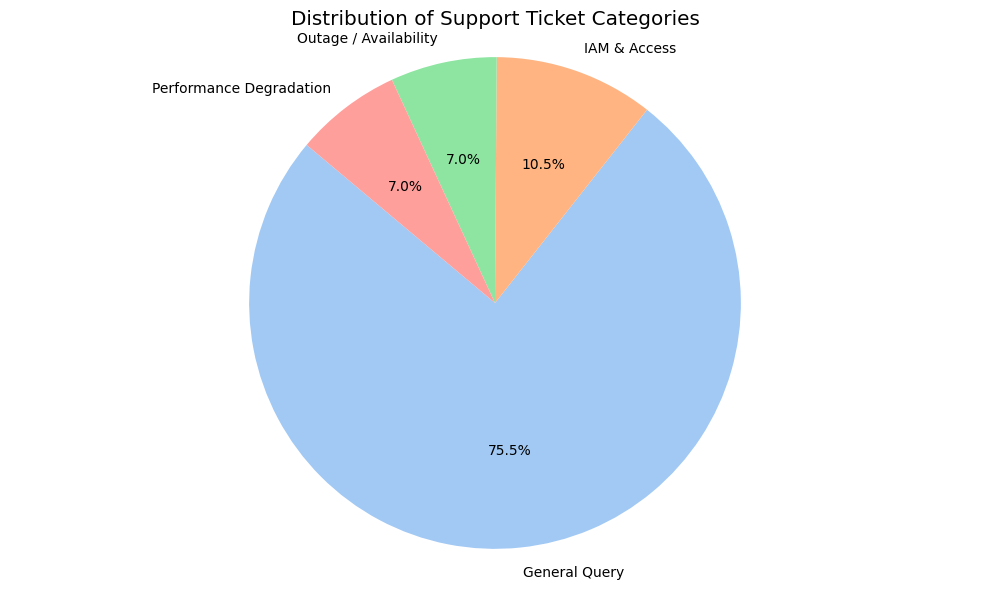

In [31]:
# Graphing T15 Output
if not df_t15.empty:
    plt.figure(figsize=(10, 6))
    plt.pie(df_t15['Ticket_Count'], labels=df_t15['Ticket_Category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Distribution of Support Ticket Categories')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print("No ticket clustering data available for visualization.")


## T16: Churn Risk Signals
**Transformation Code (`transforms/t16_churn_risk.py`)** identifies accounts with a drastic drop in usage month-over-month (e.g., >50% decline), used to alert for potential churn.


In [32]:
from transforms.t16_churn_risk import run as t16_run

df_t16 = t16_run(df)
df_t16.head(10)


✅ T16 — Churn Risk Signals generated
   Accounts at Risk: 189


,Account_ID,Month,Total_Usage,Prev_Month_Usage,MoM_Usage_Change_Pct,Risk_Level
1,AWS-ACCT-001,2026-02,3.6016,1.259944e+08,-100.0,Critical
15,AWS-ACCT-006,2026-03,17126.9400,6.713777e+07,-100.0,Critical
21,AWS-ACCT-009,2026-03,23044.7808,1.654530e+08,-100.0,Critical
44,AWS-ACCT-017,2026-02,2.9575,1.325633e+08,-100.0,Critical
52,AWS-ACCT-020,2026-03,60935.7500,1.689975e+08,-100.0,Critical
57,AZ-ACCT-022,2026-02,71.7857,3.286024e+09,-100.0,Critical
70,AZ-ACCT-026,2026-03,3443.4400,1.318476e+08,-100.0,Critical
64,AZ-ACCT-024,2026-03,3.2922,3.208435e+04,-100.0,Critical
82,AZ-ACCT-030,2026-03,2.2031,1.576347e+08,-100.0,Critical
84,AZ-ACCT-031,2026-02,1.9683,9.420560e+03,-100.0,Critical


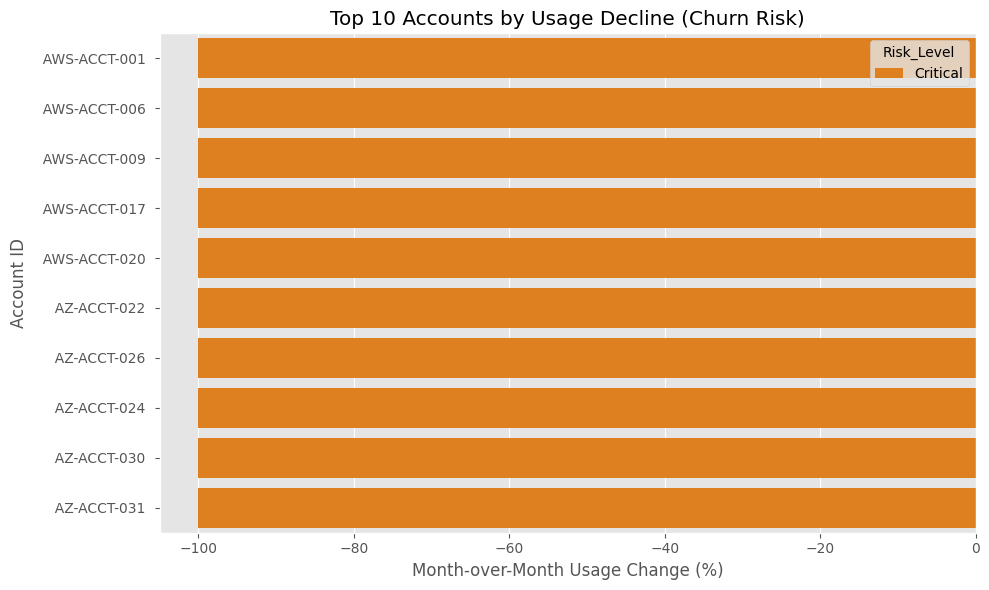

In [33]:
# Graphing T16 Output
if not df_t16.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_t16.head(10), x='MoM_Usage_Change_Pct', y='Account_ID', hue='Risk_Level', palette='autumn')
    plt.title('Top 10 Accounts by Usage Decline (Churn Risk)')
    plt.xlabel('Month-over-Month Usage Change (%)')
    plt.ylabel('Account ID')
    plt.tight_layout()
    plt.show()
else:
    print("No churn risk accounts identified.")


## T17: Unit Economics (Gross Margin Proxy)
**Transformation Code (`transforms/t17_unit_economics.py`)** estimates gross margins per account by comparing their infrastructure spend against a simulated flat SaaS subscription revenue ($500/mo).


In [34]:
from transforms.t17_unit_economics import run as t17_run

df_t17 = t17_run(df)
df_t17.head(10)


✅ T17 — Unit Economics generated
   Loss Making Accounts: 197 / 299


,Account_ID,Infra_Cost_COGS,Estimated_Revenue,Gross_Profit,Gross_Margin_Pct,Status
169,AZ-ACCT-031,251324.5926,500.0,-250824.59,-50164.9,Loss_Making
121,AWS-ACCT-017,249230.6801,500.0,-248730.68,-49746.1,Loss_Making
171,AZ-ACCT-033,214802.1612,500.0,-214302.16,-42860.4,Loss_Making
109,AWS-ACCT-005,212363.6200,500.0,-211863.62,-42372.7,Loss_Making
162,AZ-ACCT-024,205543.3644,500.0,-205043.36,-41008.7,Loss_Making
220,GCP-ACCT-037,202229.0850,500.0,-201729.08,-40345.8,Loss_Making
172,AZ-ACCT-034,201506.1732,500.0,-201006.17,-40201.2,Loss_Making
113,AWS-ACCT-009,195445.5070,500.0,-194945.51,-38989.1,Loss_Making
117,AWS-ACCT-013,193718.7900,500.0,-193218.79,-38643.8,Loss_Making
123,AWS-ACCT-019,190417.2468,500.0,-189917.25,-37983.4,Loss_Making


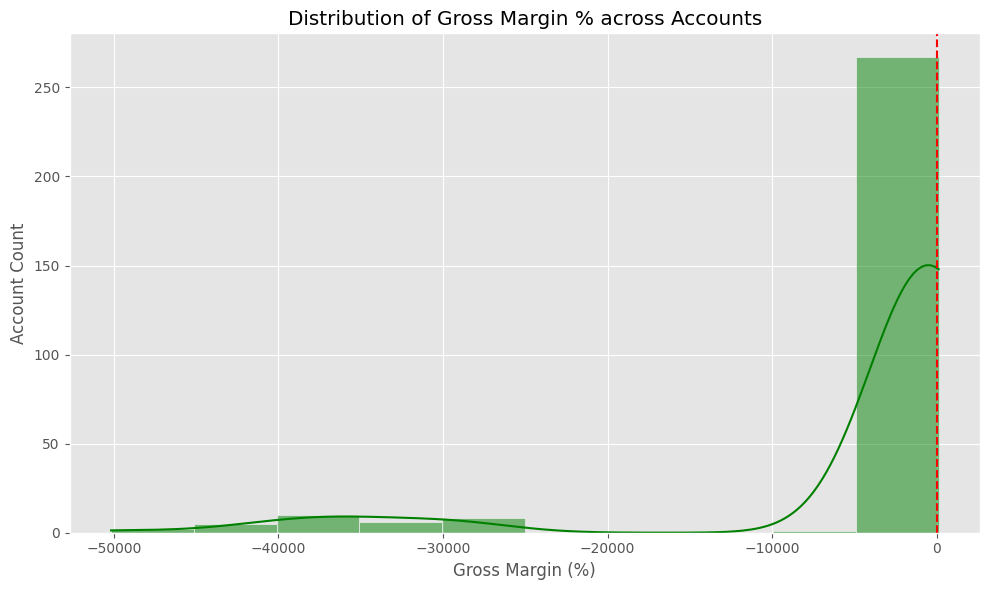

In [35]:
# Graphing T17 Output
if not df_t17.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_t17, x='Gross_Margin_Pct', bins=10, kde=True, color='green')
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Distribution of Gross Margin % across Accounts')
    plt.xlabel('Gross Margin (%)')
    plt.ylabel('Account Count')
    plt.tight_layout()
    plt.show()
else:
    print("No unit economics data available for visualization.")


## T18: Multi-Cloud Consolidation View
**Transformation Code (`transforms/t18_multicloud_consolidation.py`)** creates a master pivot unifying AWS, Azure, and GCP spend by canonical Service and Region, summarizing cross-cloud infrastructure costs.


In [36]:
from transforms.t18_multicloud_consolidation import run as t18_run

df_t18 = t18_run(df)
df_t18.head(10)


✅ T18 — Multi-Cloud Consolidation Pivot generated


Cloud_Provider,Service_Clean,Region_Clean,AWS,AZURE,GCP,Total_MultiCloud_Spend
1,Compute,ap-south-1,259555.60074,0.00000,0.0,259555.60074
15,Compute,westeurope,0.00000,258372.88918,0.0,258372.88918
18,Database,ap-southeast-1,252619.76900,0.00000,0.0,252619.76900
13,Compute,us-west-2,250128.90810,0.00000,0.0,250128.90810
12,Compute,us-east-1,234045.31322,0.00000,0.0,234045.31322
2,Compute,ap-southeast-1,226890.51672,0.00000,0.0,226890.51672
24,Database,eu-west-1,226822.01276,0.00000,0.0,226822.01276
5,Compute,canadacentral,0.00000,225749.45424,0.0,225749.45424
17,Database,ap-south-1,218368.85726,0.00000,0.0,218368.85726
10,Compute,southeastasia,0.00000,218028.85160,0.0,218028.85160


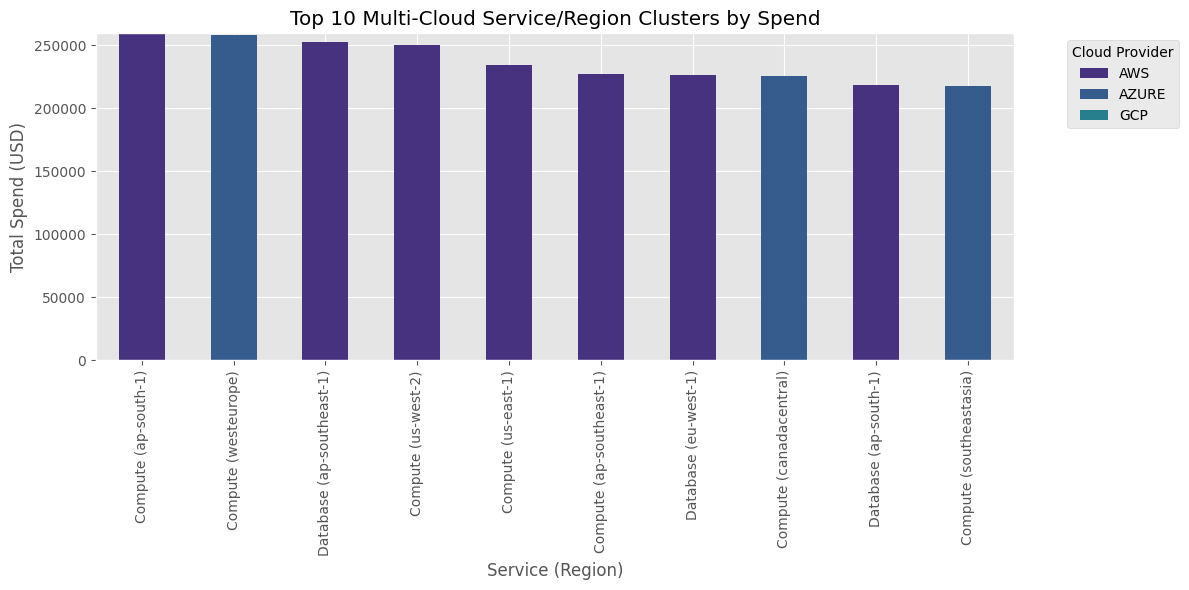

In [37]:
# Graphing T18 Output
if not df_t18.empty:
    # Use a copy to avoid SettingWithCopyWarning
    top_10 = df_t18.head(10).copy()
    top_10['Service_Region'] = top_10['Service_Clean'] + " (" + top_10['Region_Clean'] + ")"
    
    # Identify provider columns
    ignore = ['Service_Clean', 'Region_Clean', 'Total_MultiCloud_Spend', 'Service_Region']
    providers = [c for c in top_10.columns if c not in ignore]
    
    top_10.set_index('Service_Region')[providers].plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title('Top 10 Multi-Cloud Service/Region Clusters by Spend')
    plt.ylabel('Total Spend (USD)')
    plt.xlabel('Service (Region)')
    plt.legend(title='Cloud Provider', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No multi-cloud consolidation data available for visualization.")


## T19: Security Event Correlation
**Transformation Code (`transforms/t19_security_correlation.py`)** investigates compromised resources by correlating High Severity security tickets with massive cost anomalies (Z-Score > 3).


In [38]:
from transforms.t19_security_correlation import run as t19_run

df_t19 = t19_run(df)
if df_t19 is not None and not df_t19.empty:
    display(df_t19.head(10))
else:
    print("No compromised resource correlations found.")


✅ T19 — Security Event Correlation generated
   Suspected Compromised Resources: 43
   Associated Cost Risk: $33870.51


,Resource_ID,Ticket_ID,Anomaly_Events_Count,Peak_Z_Score,Total_Compromise_Cost
20,az-vm-141,T-016,1,22.591,4233.0000
31,gcp-inst-234,T-124,1,52.308,3783.1400
0,aws-ec2-002,T-104,2,31.963,3457.2702
12,aws-ec2-109,T-079,1,38.504,3418.1244
17,aws-ec2-999,T-107,1,16.456,2975.8600
32,gcp-inst-238,T-021,1,50.604,2617.0020
13,aws-ec2-110,T-132,1,NaN,2429.8021
24,az-vm-194,T-002,1,34.410,1695.4488
23,az-vm-153,T-081,1,31.418,1663.9413
21,az-vm-146,T-076,1,27.241,1591.9632


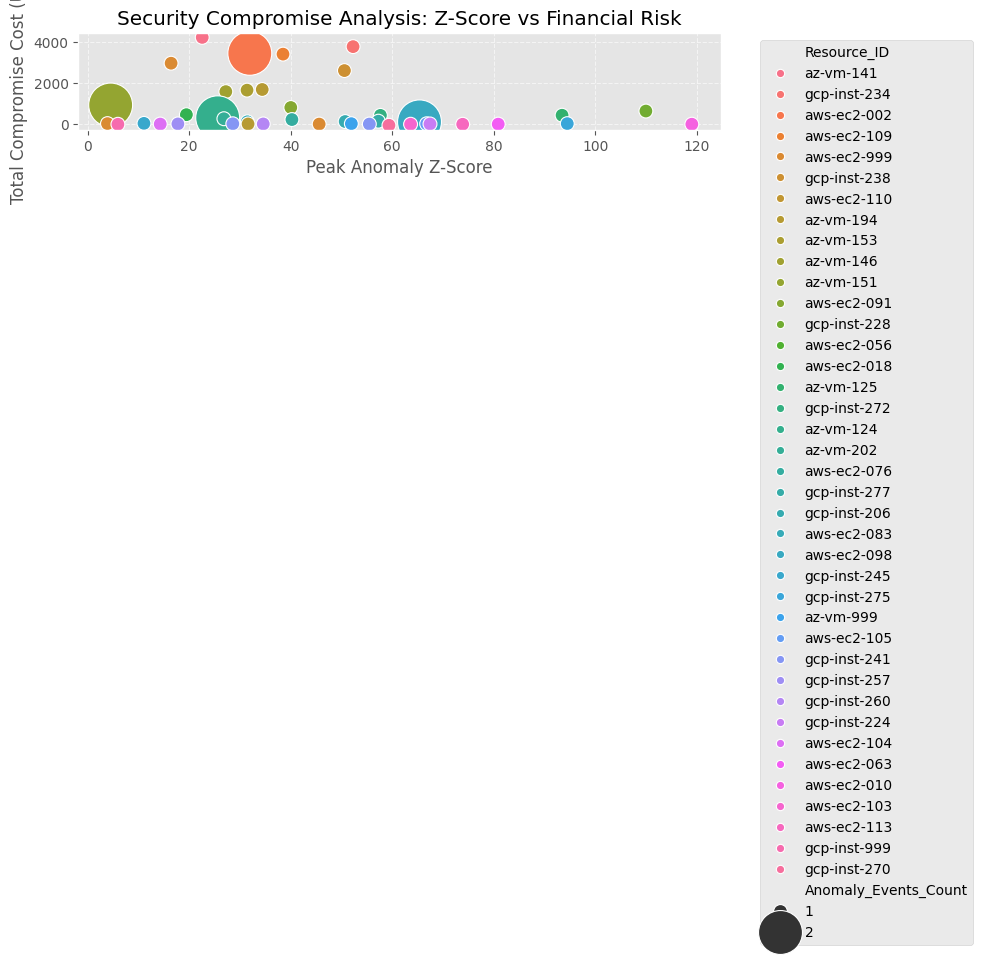

In [39]:
# Graphing T19 Output
if df_t19 is not None and not df_t19.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_t19, x='Peak_Z_Score', y='Total_Compromise_Cost', size='Anomaly_Events_Count', sizes=(100, 1000), hue='Resource_ID')
    plt.title('Security Compromise Analysis: Z-Score vs Financial Risk')
    plt.xlabel('Peak Anomaly Z-Score')
    plt.ylabel('Total Compromise Cost (USD)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No security event data available for visualization.")


## T20: Public Dashboard Extracts
**Transformation Code (`transforms/t20_public_dash.py`)** pre-computes high-level JSON data for frontend dashboards, summarizing the top accounts and services by spend.


In [40]:
from transforms.t20_public_dash import run as t20_run

dash_data = t20_run(df)
import json
print(json.dumps(dash_data, indent=2))


✅ T20 — Public Dashboard Extracts generated
{
  "top_5_accounts": [
    {
      "account": "AZ-ACCT-031",
      "cost_usd": 251324.59
    },
    {
      "account": "AWS-ACCT-017",
      "cost_usd": 249230.68
    },
    {
      "account": "AZ-ACCT-033",
      "cost_usd": 214802.16
    },
    {
      "account": "AWS-ACCT-005",
      "cost_usd": 212363.62
    },
    {
      "account": "AZ-ACCT-024",
      "cost_usd": 205543.36
    }
  ],
  "top_3_services": [
    {
      "service": "Compute",
      "cost_usd": 3077214.58
    },
    {
      "service": "Database",
      "cost_usd": 2938875.74
    },
    {
      "service": "Storage",
      "cost_usd": 412366.93
    }
  ]
}


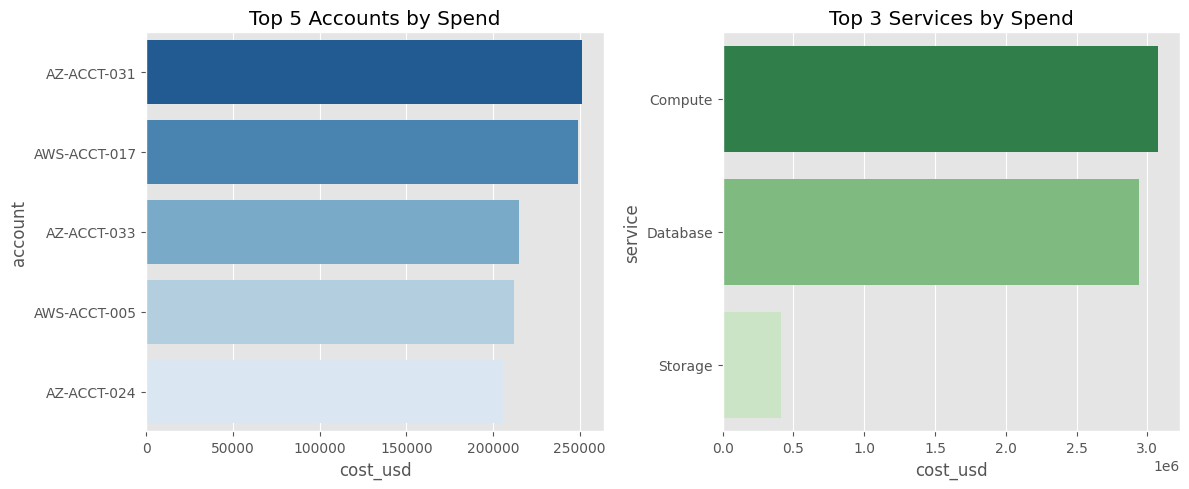

In [41]:
# Graphing T20 Output
if dash_data:
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Top 5 Accounts
    plt.subplot(1, 2, 1)
    acc_df = pd.DataFrame(dash_data['top_5_accounts'])
    sns.barplot(data=acc_df, x='cost_usd', y='account', palette='Blues_r')
    plt.title('Top 5 Accounts by Spend')
    
    # Plot 2: Top 3 Services
    plt.subplot(1, 2, 2)
    svc_df = pd.DataFrame(dash_data['top_3_services'])
    sns.barplot(data=svc_df, x='cost_usd', y='service', palette='Greens_r')
    plt.title('Top 3 Services by Spend')
    
    plt.tight_layout()
    plt.show()
else:
    print("No dashboard data available for visualization.")
